Quadratic toy model target Ne* = 1.4
Physics log: uvt_physics.log
Restart log: uvt_stable_restart.log
Physics test: compare tail averages against the analytic quadratic target.
Restart test: compare the last point before restart with the first point after restart.
Physics log: uvt_physics.log (5001 thermo rows)


,tail_mean,target,abs_error
Temp,0.998470,1.0,0.001530
Ne,1.402852,1.4,0.002852
dE/dN,2.014259,2.0,0.014259
Ne_dot,-0.000049,0.0,0.000049
f_cp drift,-0.014609,0.0,0.014609


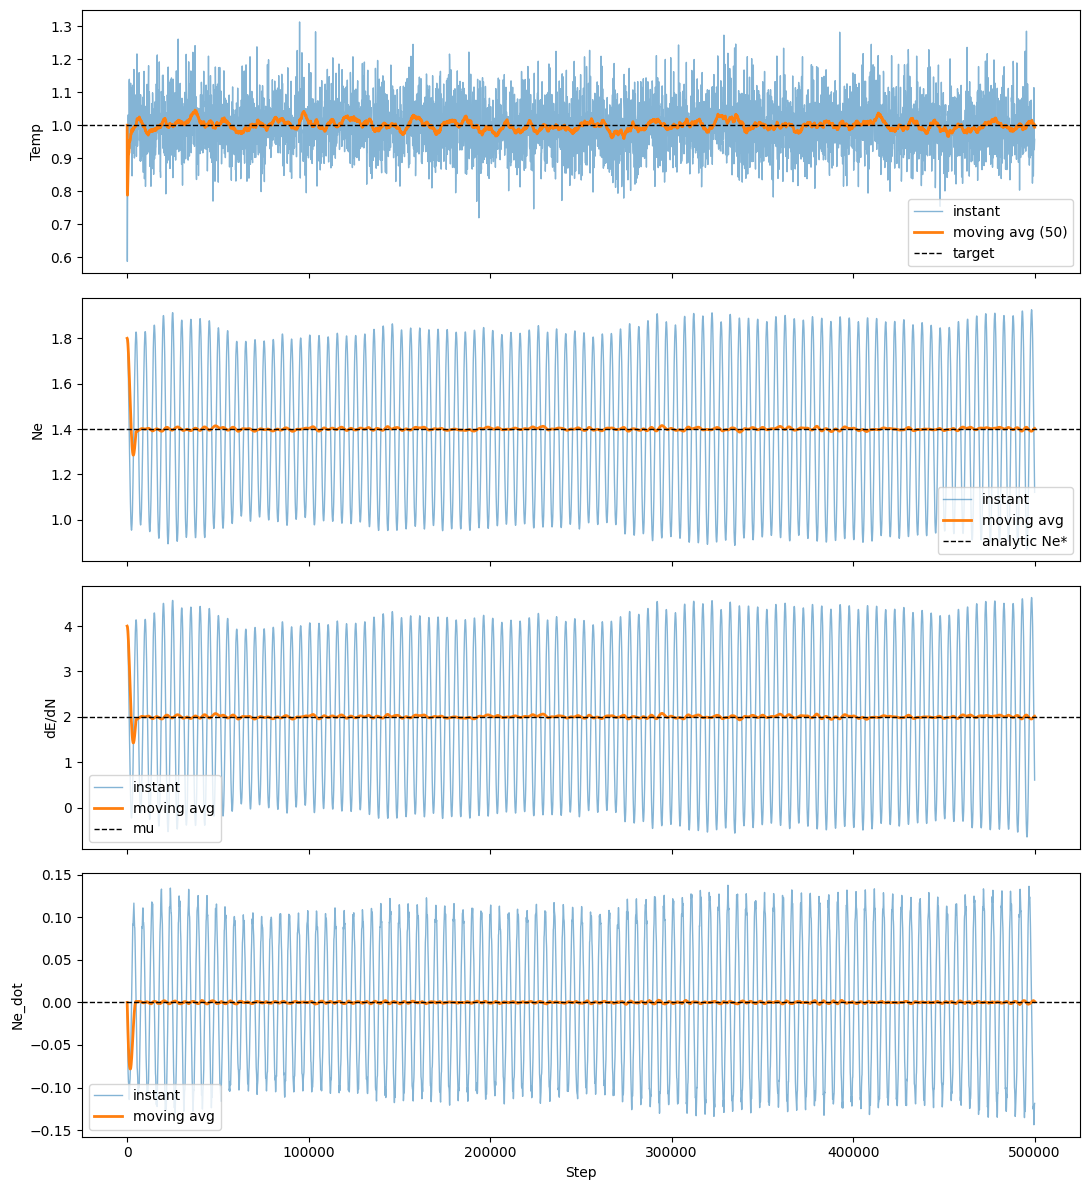

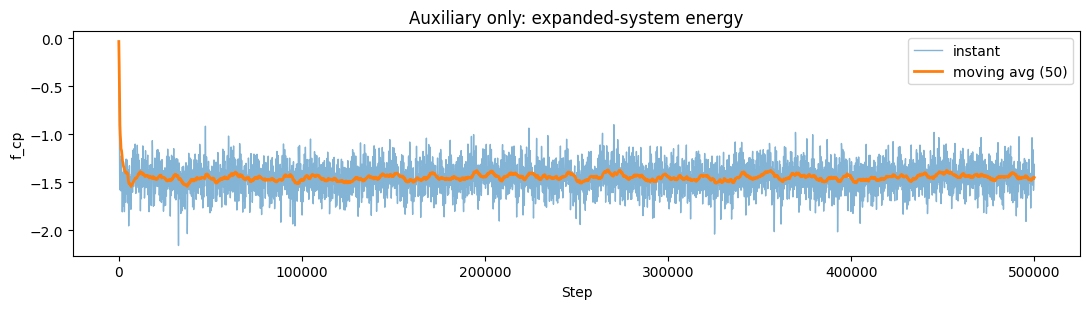

physics check Temp: error=0.0015297, tol=0.03
physics check Ne: error=0.0028519, tol=0.02
physics check dE/dN: error=0.0142595, tol=0.02
physics check Ne_dot: error=4.9429e-05, tol=0.01
Physics regression: PASS
Restart log: uvt_stable_restart.log (51 thermo rows)


,pre_last,post_first,jump
Step,500000.000000,500000.000000,0.00000
Ne,1.121251,1.121251,0.00000
Ne_dot,-0.118620,-0.118620,0.00000
dE/dN,0.606255,0.606255,0.00000
f_cp,-1.468851,-1.468921,-0.00007


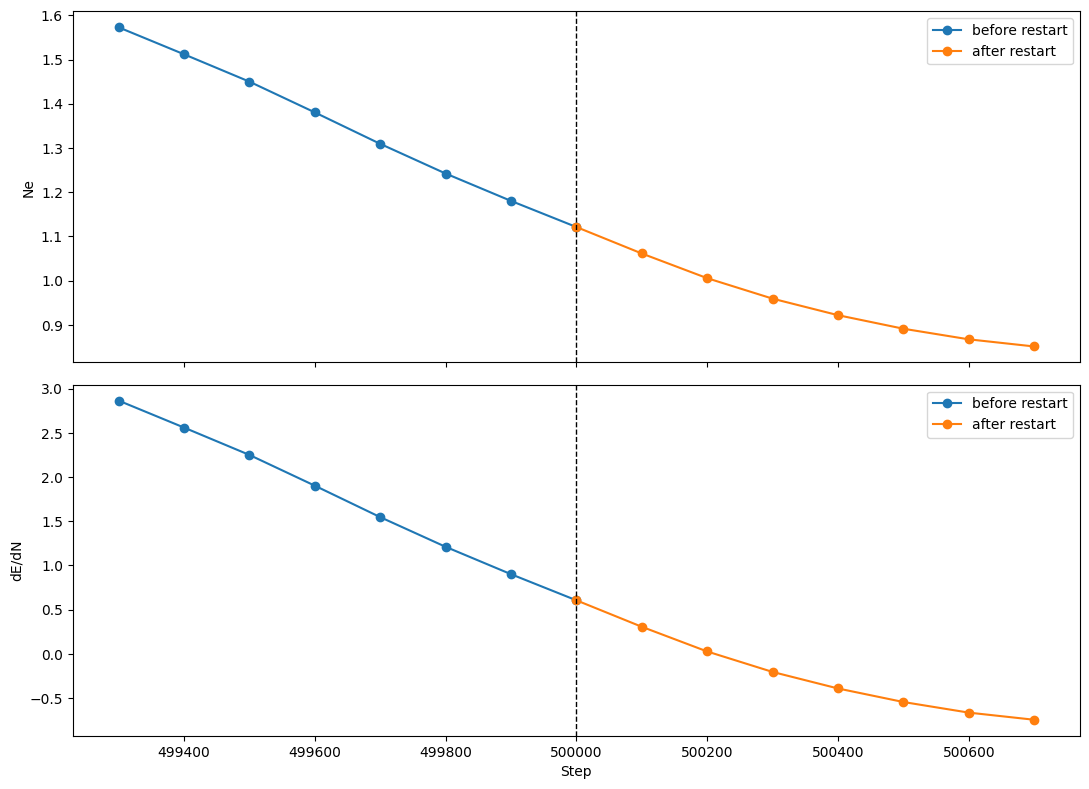

restart check Step: jump=0, tol=1e-12
restart check Ne: jump=0, tol=1e-12
restart check Ne_dot: jump=0, tol=1e-12
restart check dE/dN: jump=0, tol=1e-12
Restart regression: PASS


In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

MOVING_WINDOW = 50
TAIL_FRACTION = 0.5

MU_TARGET = 2.0
K_QUAD = 5.0
N0_QUAD = 1.0
NE_TARGET = N0_QUAD + MU_TARGET / K_QUAD

PHYSICS_TOLS = {
    "Temp": 0.03,
    "Ne": 0.02,
    "dE/dN": 0.02,
    "Ne_dot": 0.01,
}
RESTART_TOL = 1e-12


def _is_float_row(line, ncols):
    parts = line.split()
    if len(parts) != ncols:
        return False
    try:
        [float(x) for x in parts]
        return True
    except ValueError:
        return False


def read_lammps_blocks(path):
    path = Path(path)
    blocks = []
    headers = None
    data = []

    with path.open() as f:
        for raw in f:
            line = raw.strip()
            if not line:
                continue

            stripped = line.lstrip()
            if stripped.startswith("Step "):
                if headers is not None and data:
                    blocks.append(pd.DataFrame(data, columns=headers))
                headers = stripped.split()
                data = []
                continue

            if headers is None:
                continue

            if _is_float_row(line, len(headers)):
                data.append([float(x) for x in line.split()])
            else:
                if data:
                    blocks.append(pd.DataFrame(data, columns=headers))
                    data = []
                headers = None

    if headers is not None and data:
        blocks.append(pd.DataFrame(data, columns=headers))

    if not blocks:
        raise ValueError(f"No thermo blocks found in {path}")

    return blocks


def select_thermo_log(candidates):
    tried = []
    for candidate in candidates:
        path = Path(candidate)
        tried.append(str(path))
        if not path.exists():
            continue
        try:
            blocks = read_lammps_blocks(path)
        except ValueError:
            continue
        return path, blocks
    raise FileNotFoundError(f"None of these candidates contained thermo blocks: {tried}")


cwd_name = Path.cwd().name
if cwd_name == "electron-uvt":
    physics_candidates = ["uvt_physics.log", "examples/electron-uvt/uvt_physics.log"]
    restart_candidates = ["uvt_stable_restart.log", "examples/electron-uvt/uvt_stable_restart.log"]
else:
    physics_candidates = ["examples/electron-uvt/uvt_physics.log", "uvt_physics.log"]
    restart_candidates = ["examples/electron-uvt/uvt_stable_restart.log", "uvt_stable_restart.log"]

PHYSICS_LOG, physics_blocks = select_thermo_log(physics_candidates)
RESTART_LOG, restart_blocks = select_thermo_log(restart_candidates)

print(f"Quadratic toy model target Ne* = {NE_TARGET:.8g}")
print(f"Physics log: {PHYSICS_LOG}")
print(f"Restart log: {RESTART_LOG}")
print("Physics test: compare tail averages against the analytic quadratic target.")
print("Restart test: compare the last point before restart with the first point after restart.")


def stitch_blocks(blocks):
    frames = []
    step_offset = 0.0
    last_step = None

    for rid, block in enumerate(blocks):
        b = block.copy()
        b["run_id"] = rid
        if "Step" not in b.columns:
            continue
        if last_step is None:
            b["Step"] = b["Step"].astype(float)
        else:
            if b["Step"].iloc[0] <= last_step:
                b["Step"] = b["Step"] + step_offset
            else:
                b["Step"] = b["Step"].astype(float)
        step_offset = float(b["Step"].iloc[-1])
        last_step = float(b["Step"].iloc[-1])
        frames.append(b)

    if not frames:
        raise ValueError("No usable thermo frames found")

    return pd.concat(frames, ignore_index=True)


def normalize_columns(df):
    rename = {}
    for col in df.columns:
        if col.startswith("v_"):
            rename[col] = col[2:]
    out = df.rename(columns=rename).copy()
    if "NeDot" in out.columns and "Ne_dot" not in out.columns:
        out = out.rename(columns={"NeDot": "Ne_dot"})
    return out


def load_log(path):
    return normalize_columns(stitch_blocks(read_lammps_blocks(path)))


def enrich(out):
    out = out.copy()
    for c in ["Temp", "Ne", "Ne_dot", "dEdN", "dEdNfix", "f_cp"]:
        out[f"{c}_mov"] = out[c].rolling(MOVING_WINDOW, min_periods=1).mean()
        out[f"{c}_mean"] = out[c].expanding().mean()
    out["dedn_minus_mu"] = out["dEdN"] - MU_TARGET
    out["ne_drift"] = out["Ne"] - out["Ne"].iloc[0]
    return out


def tail_summary(out):
    start = int(len(out) * (1.0 - TAIL_FRACTION))
    tail = out.iloc[start:]
    summary = pd.DataFrame(
        {
            "tail_mean": [
                tail["Temp"].mean(),
                tail["Ne"].mean(),
                tail["dEdN"].mean(),
                tail["Ne_dot"].mean(),
                tail["f_cp"].iloc[-1] - tail["f_cp"].iloc[0],
            ],
            "target": [1.0, NE_TARGET, MU_TARGET, 0.0, 0.0],
            "abs_error": [
                abs(tail["Temp"].mean() - 1.0),
                abs(tail["Ne"].mean() - NE_TARGET),
                abs(tail["dEdN"].mean() - MU_TARGET),
                abs(tail["Ne_dot"].mean()),
                abs(tail["f_cp"].iloc[-1] - tail["f_cp"].iloc[0]),
            ],
        },
        index=["Temp", "Ne", "dE/dN", "Ne_dot", "f_cp drift"],
    )
    return tail, summary


def plot_physics(out):
    fig, axes = plt.subplots(4, 1, figsize=(11, 12), sharex=True)

    axes[0].plot(out["Step"], out["Temp"], lw=1, alpha=0.55, label="instant")
    axes[0].plot(out["Step"], out["Temp_mov"], lw=2, label=f"moving avg ({MOVING_WINDOW})")
    axes[0].axhline(1.0, color="k", ls="--", lw=1, label="target")
    axes[0].set_ylabel("Temp")
    axes[0].legend()

    axes[1].plot(out["Step"], out["Ne"], lw=1, alpha=0.55, label="instant")
    axes[1].plot(out["Step"], out["Ne_mov"], lw=2, label="moving avg")
    axes[1].axhline(NE_TARGET, color="k", ls="--", lw=1, label="analytic Ne*")
    axes[1].set_ylabel("Ne")
    axes[1].legend()

    axes[2].plot(out["Step"], out["dEdN"], lw=1, alpha=0.55, label="instant")
    axes[2].plot(out["Step"], out["dEdN_mov"], lw=2, label="moving avg")
    axes[2].axhline(MU_TARGET, color="k", ls="--", lw=1, label="mu")
    axes[2].set_ylabel("dE/dN")
    axes[2].legend()

    axes[3].plot(out["Step"], out["Ne_dot"], lw=1, alpha=0.55, label="instant")
    axes[3].plot(out["Step"], out["Ne_dot_mov"], lw=2, label="moving avg")
    axes[3].axhline(0.0, color="k", ls="--", lw=1)
    axes[3].set_ylabel("Ne_dot")
    axes[3].set_xlabel("Step")
    axes[3].legend()

    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(1, 1, figsize=(11, 3.2), sharex=True)
    ax.plot(out["Step"], out["f_cp"], lw=1, alpha=0.55, label="instant")
    ax.plot(out["Step"], out["f_cp_mov"], lw=2, label=f"moving avg ({MOVING_WINDOW})")
    ax.set_ylabel("f_cp")
    ax.set_xlabel("Step")
    ax.set_title("Auxiliary only: expanded-system energy")
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_restart_window(pre, post):
    pre_tail = pre.tail(8).copy()
    post_head = post.head(8).copy()
    post_head["StepDisplay"] = post_head["Step"] + (pre_tail["Step"].iloc[-1] - post_head["Step"].iloc[0])
    pre_tail["StepDisplay"] = pre_tail["Step"]

    fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

    axes[0].plot(pre_tail["StepDisplay"], pre_tail["Ne"], marker="o", label="before restart")
    axes[0].plot(post_head["StepDisplay"], post_head["Ne"], marker="o", label="after restart")
    axes[0].axvline(pre_tail["StepDisplay"].iloc[-1], color="k", ls="--", lw=1)
    axes[0].set_ylabel("Ne")
    axes[0].legend()

    axes[1].plot(pre_tail["StepDisplay"], pre_tail["dEdN"], marker="o", label="before restart")
    axes[1].plot(post_head["StepDisplay"], post_head["dEdN"], marker="o", label="after restart")
    axes[1].axvline(pre_tail["StepDisplay"].iloc[-1], color="k", ls="--", lw=1)
    axes[1].set_ylabel("dE/dN")
    axes[1].set_xlabel("Step")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


physics = enrich(load_log(PHYSICS_LOG))
print(f"Physics log: {PHYSICS_LOG} ({len(physics)} thermo rows)")
tail, physics_summary = tail_summary(physics)
display(physics_summary)
plot_physics(physics)

physics_ok = True
for label, tol in PHYSICS_TOLS.items():
    err = float(physics_summary.loc[label, "abs_error"])
    physics_ok &= err <= tol
    print(f"physics check {label}: error={err:.6g}, tol={tol:.6g}")

print("Physics regression:", "PASS" if physics_ok else "FAIL")
assert physics_ok, "Physics regression failed"

restart = enrich(load_log(RESTART_LOG))
print(f"Restart log: {RESTART_LOG} ({len(restart)} thermo rows)")

pre_last = physics.iloc[-1]
post_first = restart.iloc[0]
restart_summary = pd.DataFrame(
    {
        "pre_last": [pre_last["Step"], pre_last["Ne"], pre_last["Ne_dot"], pre_last["dEdN"], pre_last["f_cp"]],
        "post_first": [post_first["Step"], post_first["Ne"], post_first["Ne_dot"], post_first["dEdN"], post_first["f_cp"]],
        "jump": [post_first["Step"] - pre_last["Step"], post_first["Ne"] - pre_last["Ne"], post_first["Ne_dot"] - pre_last["Ne_dot"], post_first["dEdN"] - pre_last["dEdN"], post_first["f_cp"] - pre_last["f_cp"]],
    },
    index=["Step", "Ne", "Ne_dot", "dE/dN", "f_cp"],
)
display(restart_summary)
plot_restart_window(physics, restart)

restart_ok = True
for label in ["Step", "Ne", "Ne_dot", "dE/dN"]:
    jump = abs(float(restart_summary.loc[label, "jump"]))
    restart_ok &= jump <= RESTART_TOL
    print(f"restart check {label}: jump={jump:.6g}, tol={RESTART_TOL:.6g}")

print("Restart regression:", "PASS" if restart_ok else "FAIL")
assert restart_ok, "Restart continuity regression failed"
